In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from fugw.mappings import FUGW
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, MutableMapping, Tuple
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
from pathlib import Path
from src.align import *
from src.evaluate import *
from src.features import *
from src.process import *
from src.utils import *
from src.vis import *
import src.evaluate as eval
from typing import Dict, Iterable, Iterator, List, Sequence, Tuple

### Results

In [4]:
category = "CG"
import src.evaluate as eval
family = load_family_data(Path(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1"))
sim_mat = eval._similarity_matrix_from_file(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim", 
source_nodes=list(family.graphs["A"].nodes()), target_nodes=list(family.graphs["B"].nodes()))
run_dir_p = Path(f"/home/bcl/wanghongyu/other/networkscience/outputs/2way/{category}/family1/A_vs_B/")
run_dir = run_dir_p / Path(os.listdir(run_dir_p)[0])

2026-01-12 14:53:23,579 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2026-01-12 14:53:23,611 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2026-01-12 14:53:23,614 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2026-01-12 14:53:23,617 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2026-01-12 14:53:23,768 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


In [5]:
from src.utils import (
    load_cached_features,
    METADATA_FILE,
    PARAMS_FILE,
    RESULTS_FILE,
    SOURCE_FEATURE_FILE,
    TARGET_FEATURE_FILE,
    SOURCE_GEOMETRY_FILE,
    TARGET_GEOMETRY_FILE,
    COUPLING_FILE,
)

cache = load_cached_features(run_dir)
if cache:
    print("Feature tensor shape:", cache.source_features.shape)

metadata = json.loads((run_dir / METADATA_FILE).read_text(encoding="utf-8"))
params = json.loads((run_dir / PARAMS_FILE).read_text(encoding="utf-8"))
result = json.loads((run_dir / RESULTS_FILE).read_text(encoding="utf-8"))
source_nodes = metadata['source_nodes']
target_nodes = metadata['target_nodes']

source_features = torch.load(run_dir / SOURCE_FEATURE_FILE, map_location="cpu")
target_features = torch.load(run_dir / TARGET_FEATURE_FILE, map_location="cpu")
feature_mat = (source_features.unsqueeze(1) - target_features.unsqueeze(0)).square().sum(dim=-1)
print(feature_mat.shape)
source_geometry = torch.load(run_dir / SOURCE_GEOMETRY_FILE, map_location="cpu")
target_geometry = torch.load(run_dir / TARGET_GEOMETRY_FILE, map_location="cpu")
coupling = torch.load(run_dir / COUPLING_FILE, map_location="cpu")
pi = coupling.clone() / coupling.sum()
pi = pi.cpu().numpy()

Feature tensor shape: torch.Size([3000, 5])
torch.Size([3000, 4000])


In [6]:
# 对于每行/每列只保留最大值的位置，其余为零，然后归一化
pi_hard1 = np.zeros_like(pi)
row_max_indices = np.argmax(pi, axis=1)
pi_hard1[np.arange(pi.shape[0]), row_max_indices] = 1
pi_hard1 = pi_hard1 / pi_hard1.sum()

pi_hard2 = np.zeros_like(pi)
col_max_indices = np.argmax(pi, axis=0)
pi_hard2[col_max_indices, np.arange(pi.shape[1])] = 1
pi_hard2 = pi_hard2 / pi_hard2.sum()

1574.095848 0.0


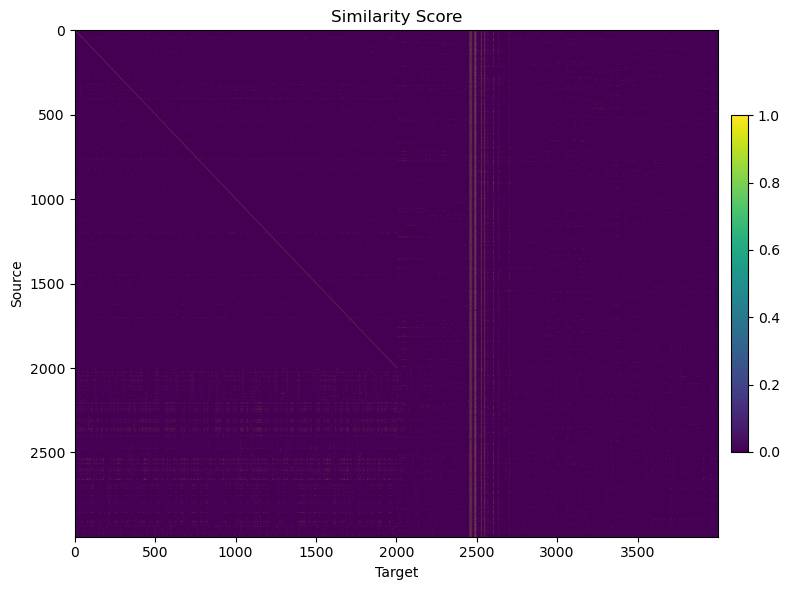

In [23]:
sim_mat = eval._similarity_matrix_from_file(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim", 
source_nodes=family.graphs["A"].nodes(), target_nodes=family.graphs["B"].nodes())
plot_heatmap(1-np.exp(-sim_mat), title="Similarity Score")
print(sim_mat.max(), sim_mat.min())

0.001018574 0.0


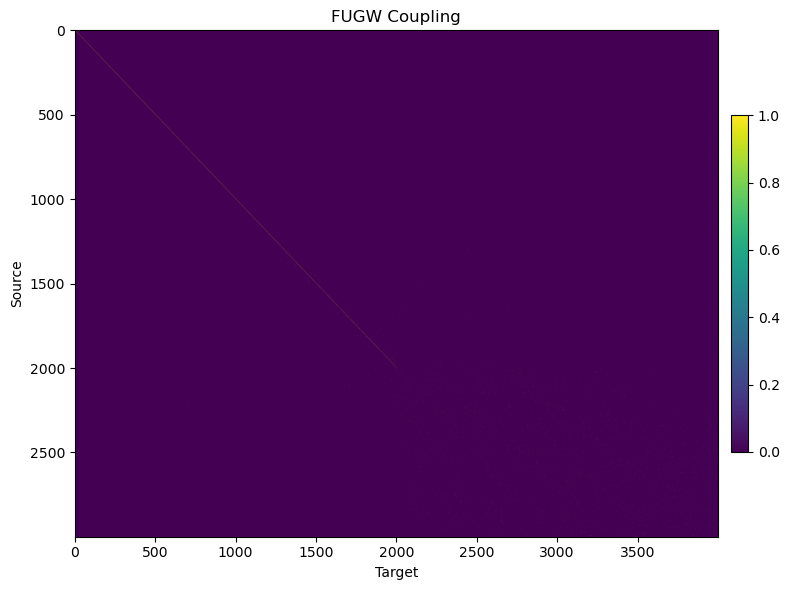

In [24]:
plot_heatmap(1-np.exp(-pi*1e6), title="FUGW Coupling")
print(pi.max(), pi.min())

done


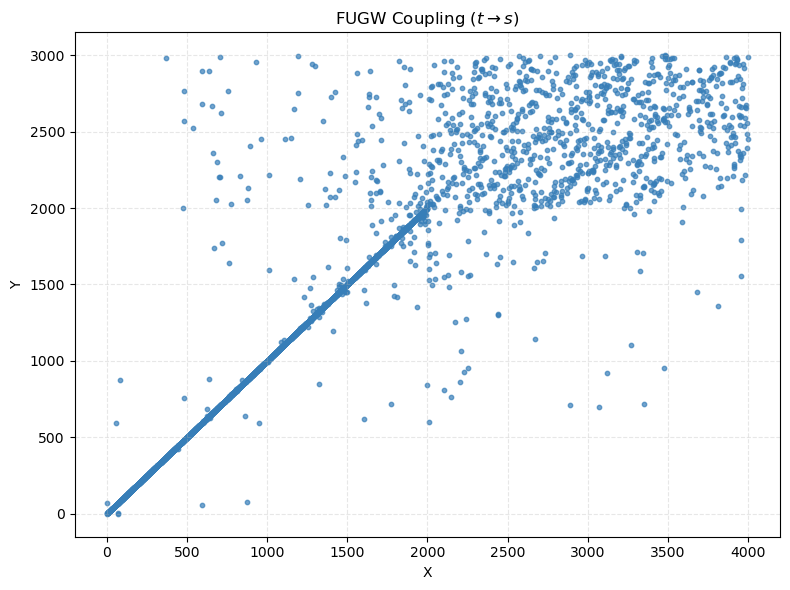

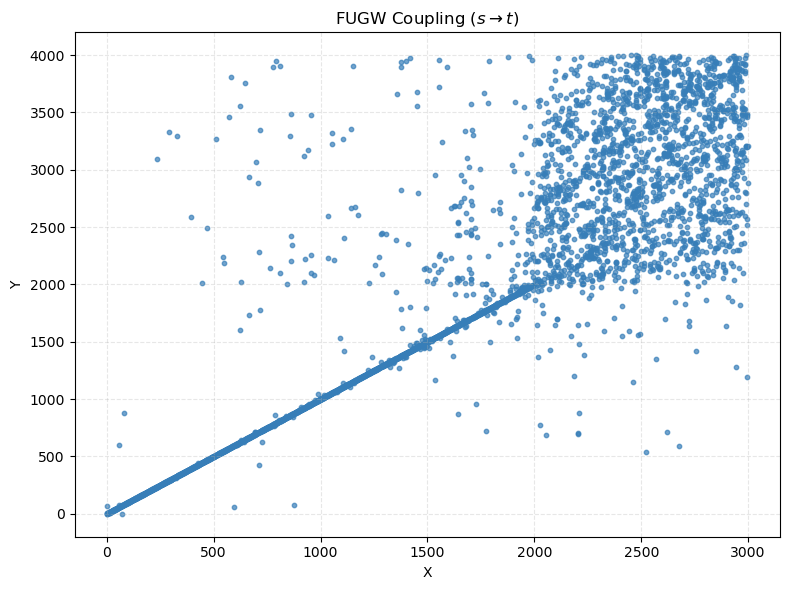

In [37]:
plot_scatter(pi_hard1, title=r"FUGW Coupling ($t\to s$)", reverse_xy=True, direct=False)
plot_scatter(pi_hard2, title=r"FUGW Coupling ($s\to t$)", reverse_xy=False, direct=False)
print("done")

#### IsoRankN

In [11]:
def load_isorank_matrix(match_score_path, nodes_a, nodes_b):
    df = pd.read_csv(
        match_score_path,
        sep=r"\s+",
        header=None,
        names=["a", "b", "score"],
        engine="python",
    )
    idx_a = {node: i for i, node in enumerate(nodes_a)}
    idx_b = {node: j for j, node in enumerate(nodes_b)}
    matrix = np.zeros((len(nodes_a), len(nodes_b)), dtype=np.float64)
    for row in df.itertuples(index=False):
        i = idx_a.get(row.a)
        j = idx_b.get(row.b)
        if i is not None and j is not None:
            matrix[i, j] = row.score
    matrix /= matrix.sum()  # 与 FUGW 耦合一样归一化
    return matrix

def uniform_coupling_from_clusters(
    cluster_path: Path | str,
    source_nodes: Sequence[str],
    target_nodes: Sequence[str],
) -> np.ndarray:
    """
    Convert IsoRankN `final_cluster` output into a coupling matrix that preserves
    1-to-n / n-to-1 confidence.

    对每个 cluster：
    - 若只包含 1 个源节点对应多个目标节点，则每个 pair 权重为 1 / len(target)。
    - 若只包含 1 个目标节点对应多个源节点，则每个 pair 权重为 1 / len(source)。
    - 其余情况退化为源/目标节点两两均匀配对。
    最后对整张矩阵进行一次全局归一化，使其总和为 1。
    """

    source_index = {node: idx for idx, node in enumerate(source_nodes)}
    target_index = {node: idx for idx, node in enumerate(target_nodes)}
    clusters: List[Tuple[List[int], List[int]]] = []

    with Path(cluster_path).open("r", encoding="utf-8") as file_obj:
        for line in file_obj:
            tokens = line.strip().split()
            if not tokens:
                continue
            src_idx: List[int] = []
            tgt_idx: List[int] = []
            for token in tokens:
                if token in source_index:
                    src_idx.append(source_index[token])
                elif token in target_index:
                    tgt_idx.append(target_index[token])
            if src_idx and tgt_idx:
                clusters.append((src_idx, tgt_idx))

    matrix = np.zeros((len(source_nodes), len(target_nodes)), dtype=np.float64)
    if not clusters:
        return matrix

    for src_idx, tgt_idx in clusters:
        if len(src_idx) == 1 and len(tgt_idx) >= 1:
            weight = 1.0 / len(tgt_idx)
            src = src_idx[0]
            for tgt in tgt_idx:
                matrix[src, tgt] += weight
        elif len(tgt_idx) == 1 and len(src_idx) >= 1:
            weight = 1.0 / len(src_idx)
            tgt = tgt_idx[0]
            for src in src_idx:
                matrix[src, tgt] += weight
        else:
            if not src_idx or not tgt_idx:
                continue
            weight = 1.0 / (len(src_idx) * len(tgt_idx))
            for src in src_idx:
                for tgt in tgt_idx:
                    matrix[src, tgt] += weight

    total_mass = matrix.sum()
    if total_mass > 0:
        matrix /= total_mass

    return matrix


In [20]:
iso_category = "2way_CG_family1"
alpha = 1.0
iso_run_dir_p = Path(f"IsoRankN/napa_outputs/{iso_category}/alpha_{alpha}")
iso_files = sorted(os.listdir(iso_run_dir_p))
family = load_family_data(Path("data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1"))
isorank_output_score_file = iso_run_dir_p / Path(iso_files[1])
isorank_output_cluster_file = iso_run_dir_p / Path(iso_files[0])
source_nodes = list(family.graphs["A"].nodes)
target_nodes = list(family.graphs["B"].nodes)
print(isorank_output_score_file)
print(isorank_output_cluster_file)

2026-01-12 15:09:17,345 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2026-01-12 15:09:17,422 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2026-01-12 15:09:17,430 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2026-01-12 15:09:17,437 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2026-01-12 15:09:17,676 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


IsoRankN/napa_outputs/2way_CG_family1/alpha_1.0/run_20260103-114926_match-score.txt
IsoRankN/napa_outputs/2way_CG_family1/alpha_1.0/final_cluster_20260103-114926.txt


In [21]:
isorank_mat = load_isorank_matrix(isorank_output_score_file, family.graphs["A"].nodes, family.graphs["B"].nodes)
pi = isorank_mat
# 对于每行/每列只保留最大值的位置，其余为零，然后归一化
pi_hard1 = np.zeros_like(pi)
row_max_indices = np.argmax(pi, axis=1)
pi_hard1[np.arange(pi.shape[0]), row_max_indices] = 1
pi_hard1 = pi_hard1 / pi_hard1.sum()

pi_hard2 = np.zeros_like(pi)
col_max_indices = np.argmax(pi, axis=0)
pi_hard2[col_max_indices, np.arange(pi.shape[1])] = 1
pi_hard2 = pi_hard2 / pi_hard2.sum()

4.906919973696455e-05 0.0


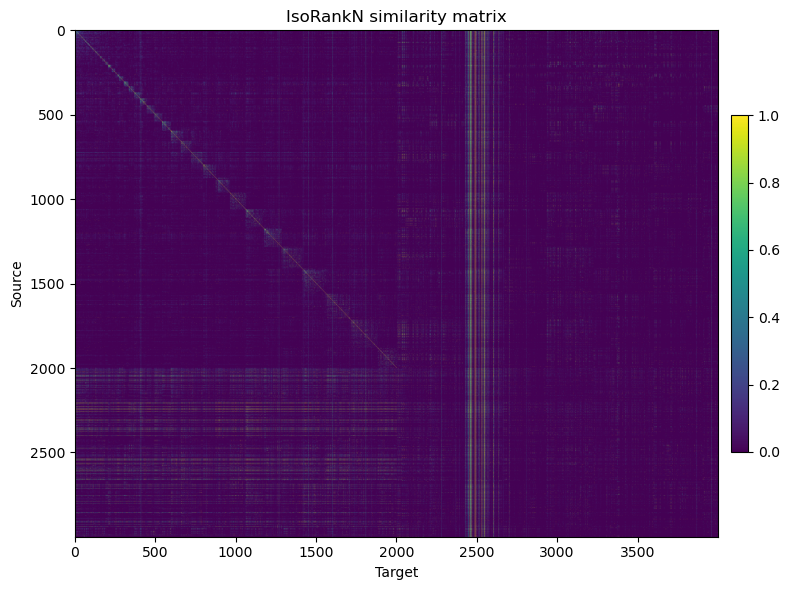

In [18]:
plot_heatmap(1-np.exp(-pi*1e6), title="IsoRankN similarity matrix")
print(pi.max(), pi.min())

3000
4000
done


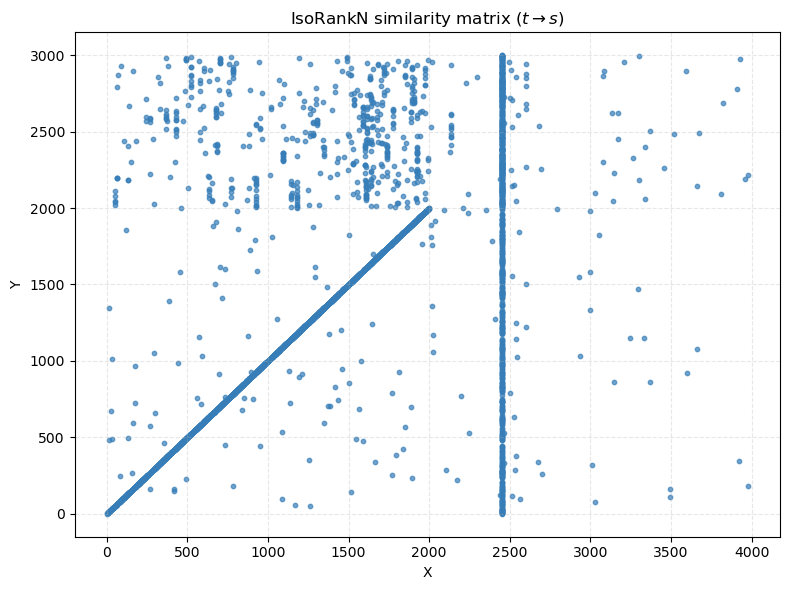

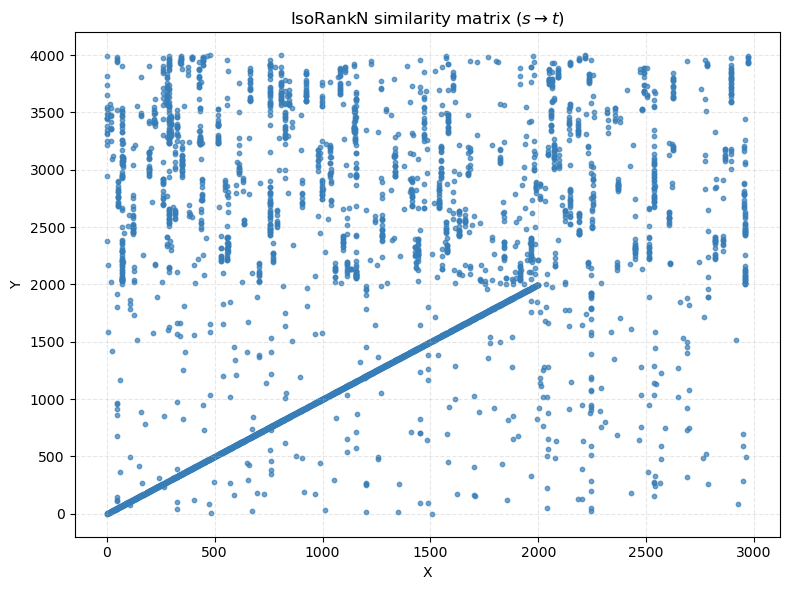

In [23]:
plot_scatter(pi_hard1, title=r"IsoRankN similarity matrix ($t\to s$)", reverse_xy=True, direct=False)
plot_scatter(pi_hard2, title=r"IsoRankN similarity matrix ($s\to t$)", reverse_xy=False, direct=False)
print("done")

In [27]:
iso_category = "2way_CG_family1"
alpha = 1.0
iso_run_dir_p = Path(f"IsoRankN/napa_outputs/{iso_category}/alpha_{alpha}")
iso_files = sorted(os.listdir(iso_run_dir_p))
family = load_family_data(Path("data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1"))
isorank_output_score_file = iso_run_dir_p / Path(iso_files[1])
isorank_output_cluster_file = iso_run_dir_p / Path(iso_files[0])
source_nodes = list(family.graphs["A"].nodes)
target_nodes = list(family.graphs["B"].nodes)
print(isorank_output_score_file)
print(isorank_output_cluster_file)

2026-01-12 15:35:56,818 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2026-01-12 15:35:56,856 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2026-01-12 15:35:56,859 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2026-01-12 15:35:56,861 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2026-01-12 15:35:57,172 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


IsoRankN/napa_outputs/2way_CG_family1/alpha_1.0/run_20260103-114926_match-score.txt
IsoRankN/napa_outputs/2way_CG_family1/alpha_1.0/final_cluster_20260103-114926.txt


In [28]:
cluster_mat = uniform_coupling_from_clusters(isorank_output_cluster_file, source_nodes, target_nodes)
pi = cluster_mat

In [29]:
# 对于每行/每列只保留最大值的位置，其余为零，然后归一化
pi_hard1 = np.zeros_like(pi)
row_max_indices = np.argmax(pi, axis=1)
pi_hard1[np.arange(pi.shape[0]), row_max_indices] = 1
pi_hard1 = pi_hard1 / pi_hard1.sum()

pi_hard2 = np.zeros_like(pi)
col_max_indices = np.argmax(pi, axis=0)
pi_hard2[col_max_indices, np.arange(pi.shape[1])] = 1
pi_hard2 = pi_hard2 / pi_hard2.sum()

0.0004837929366231253 0.0


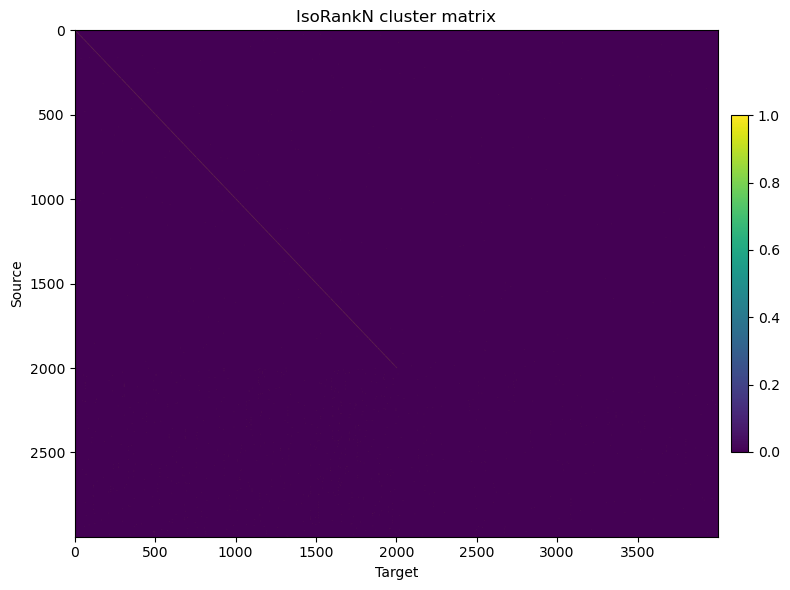

In [33]:
plot_heatmap(1-np.exp(-pi*1e6), title="IsoRankN cluster matrix")
print(pi.max(), pi.min())

3000
4000
done


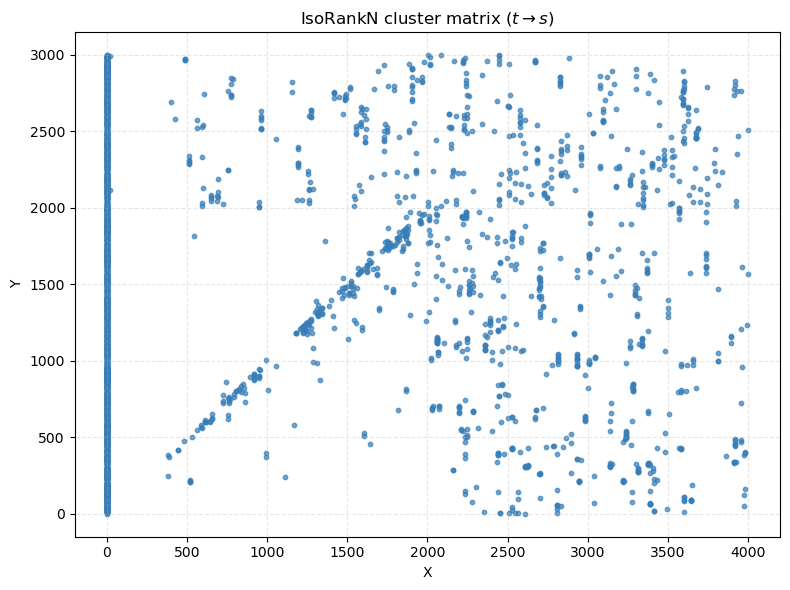

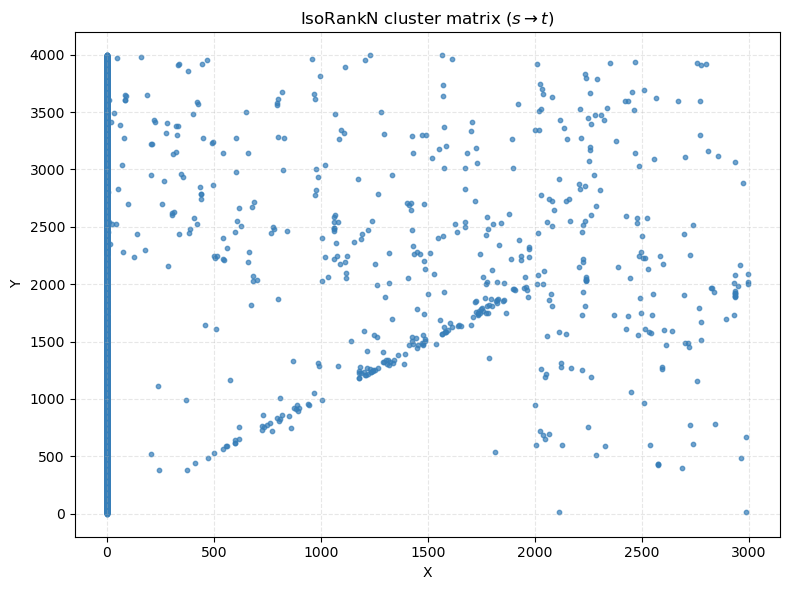

In [28]:
plot_scatter(pi_hard1, title=r"IsoRankN cluster matrix ($t\to s$)", reverse_xy=True, direct=False)
plot_scatter(pi_hard2, title=r"IsoRankN cluster matrix ($s\to t$)", reverse_xy=False, direct=False)
print("done")

In [18]:
from __future__ import annotations

from typing import Any, Dict, Optional, Tuple, Union
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

ArrayLike2D = Union[np.ndarray, "torch.Tensor"]

def plot_marginal(
    mat: ArrayLike2D,
    *,
    nonneg: str = "clip",
    eps: float = 1e-12,
    cmap: str = "mako_r",  # 使用反转的 colormap，默认从黑到白
    marginal_color: str = "#1f77b4",
    xlabel: str = "x bin",
    ylabel: str = "y bin",
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (6.6, 5.6),
    dpi: int = 300,
    font_family: str = "DejaVu Serif",
    tick_fontsize: int = 10,
    label_fontsize: int = 11,
    title_fontsize: int = 12,
    show_colorbar: bool = True,
    savepath: Optional[str] = None,
) -> Tuple["matplotlib.figure.Figure", Dict[str, Any]]:
    """
    绘制二维离散分布的“联合热图 + 边际分布”边际图（publication-quality）。

    参数
    - mat: (H, W) 二维数组（numpy 或 torch），表示权重/能量/相似度等，将被归一化为分布 P
    - nonneg: 处理负值策略
        - "raise": 若存在负值直接报错
        - "clip": 将负值裁剪为 0 后再归一化（默认）
        - "shift": 整体平移使最小值为 0 后再归一化
    - eps: (,) 防止除零的极小值阈值
    - savepath: 若提供则保存图片（例如 "figs/marginal.png"）

    返回
    - fig: matplotlib Figure
    - axes: dict，包含 "joint"（热图）、"top"（x 边际）、"right"（y 边际）、可选 "cax"
    """
    # ---- convert to numpy float ----
    if "torch" in str(type(mat)):
        # local import to avoid hard dependency in typing
        if not isinstance(mat, torch.Tensor):
            raise TypeError(f"Unsupported type: {type(mat)}")
        a = mat.detach().float().cpu().numpy()
    else:
        a = np.asarray(mat, dtype=np.float64)

    if a.ndim != 2:
        raise ValueError(f"`mat` must be 2D with shape (H, W), got shape={a.shape}")

    if not np.isfinite(a).all():
        raise ValueError("`mat` contains NaN/Inf, please clean it before plotting.")

    # ---- enforce nonnegative & normalize to probability ----
    if nonneg not in {"raise", "clip", "shift"}:
        raise ValueError("`nonneg` must be one of {'raise','clip','shift'}")

    if nonneg == "raise":
        if (a < 0).any():
            raise ValueError("`mat` has negative entries; set nonneg='clip' or 'shift'.")
        w = a
    elif nonneg == "clip":
        w = np.clip(a, 0.0, None)
    else:  # shift
        w = a - a.min()

    s = float(w.sum())
    if s <= eps:
        raise ValueError("Sum of nonnegative weights is ~0; cannot normalize to a distribution.")
    P = w / s  # (H, W)

    # ---- marginals ----
    px = P.sum(axis=0)  # (W,)
    py = P.sum(axis=1)  # (H,)

    mpl.rcParams.update(
        {
            "figure.dpi": dpi,
            "savefig.dpi": dpi,
            "font.family": font_family,
            "axes.titlesize": title_fontsize,
            "axes.labelsize": label_fontsize,
            "xtick.labelsize": tick_fontsize,
            "ytick.labelsize": tick_fontsize,
            "axes.linewidth": 0.8,
        }
    )

    try:
        sns.set_theme(style="white", context="paper")
        use_seaborn = True
    except Exception:
        use_seaborn = False

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = GridSpec(
        2,
        2,
        figure=fig,
        width_ratios=(4.2, 1.2),
        height_ratios=(1.2, 4.2),
        wspace=0.06,
        hspace=0.06,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[0, 1])  # for colorbar (or empty)

    # top marginal (x)
    x = np.arange(P.shape[1])
    ax_top.plot(x, px, color=marginal_color, lw=2.0)
    ax_top.fill_between(x, 0.0, px, color=marginal_color, alpha=0.22, linewidth=0)
    ax_top.set_xlim(-0.5, P.shape[1] - 0.5)
    ax_top.set_ylabel("p(x)")
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.grid(True, axis="y", alpha=0.25, linewidth=0.6)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["top"].set_visible(False)

    # right marginal (y)
    y = np.arange(P.shape[0])
    ax_right.plot(py, y, color=marginal_color, lw=2.0)
    ax_right.fill_betweenx(y, 0.0, py, color=marginal_color, alpha=0.22, linewidth=0)
    ax_right.set_ylim(P.shape[0] - 0.5, -0.5)
    ax_right.set_xlabel("p(y)")
    ax_right.tick_params(axis="y", labelleft=False)
    ax_right.grid(True, axis="x", alpha=0.25, linewidth=0.6)
    ax_right.spines["right"].set_visible(False)
    ax_right.spines["top"].set_visible(False)

    # joint heatmap
    # 反转颜色：默认 colormap 设为 _r 结尾或者由用户传入
    if use_seaborn:
        hm = sns.heatmap(
            P,
            ax=ax_joint,
            cmap=cmap,
            cbar=False,  # we draw cbar ourselves
            square=False,
            linewidths=0.0,
            rasterized=True,  # good for vector export
        )
        im = hm.collections[0]
    else:
        im = ax_joint.imshow(P, cmap=cmap, origin="upper", aspect="auto")
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)

    # colorbar in corner
    axes: Dict[str, Any] = {"joint": ax_joint, "top": ax_top, "right": ax_right}
    if show_colorbar:
        ax_corner.set_axis_off()
        cax = fig.add_axes(ax_corner.get_position(fig).shrunk(0.55, 0.75).translated(0.25, 0.10))
        cb = fig.colorbar(im, cax=cax, orientation="vertical")
        cb.set_label("P(x, y)")
        cb.outline.set_linewidth(0.6)
        axes["cax"] = cax
    else:
        ax_corner.set_axis_off()

    if title is not None:
        fig.suptitle(title, y=0.98)

    # tighten without over-squeezing
    fig.subplots_adjust(left=0.10, right=0.96, bottom=0.10, top=0.92)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", dpi=dpi)

    return fig, axes

Done


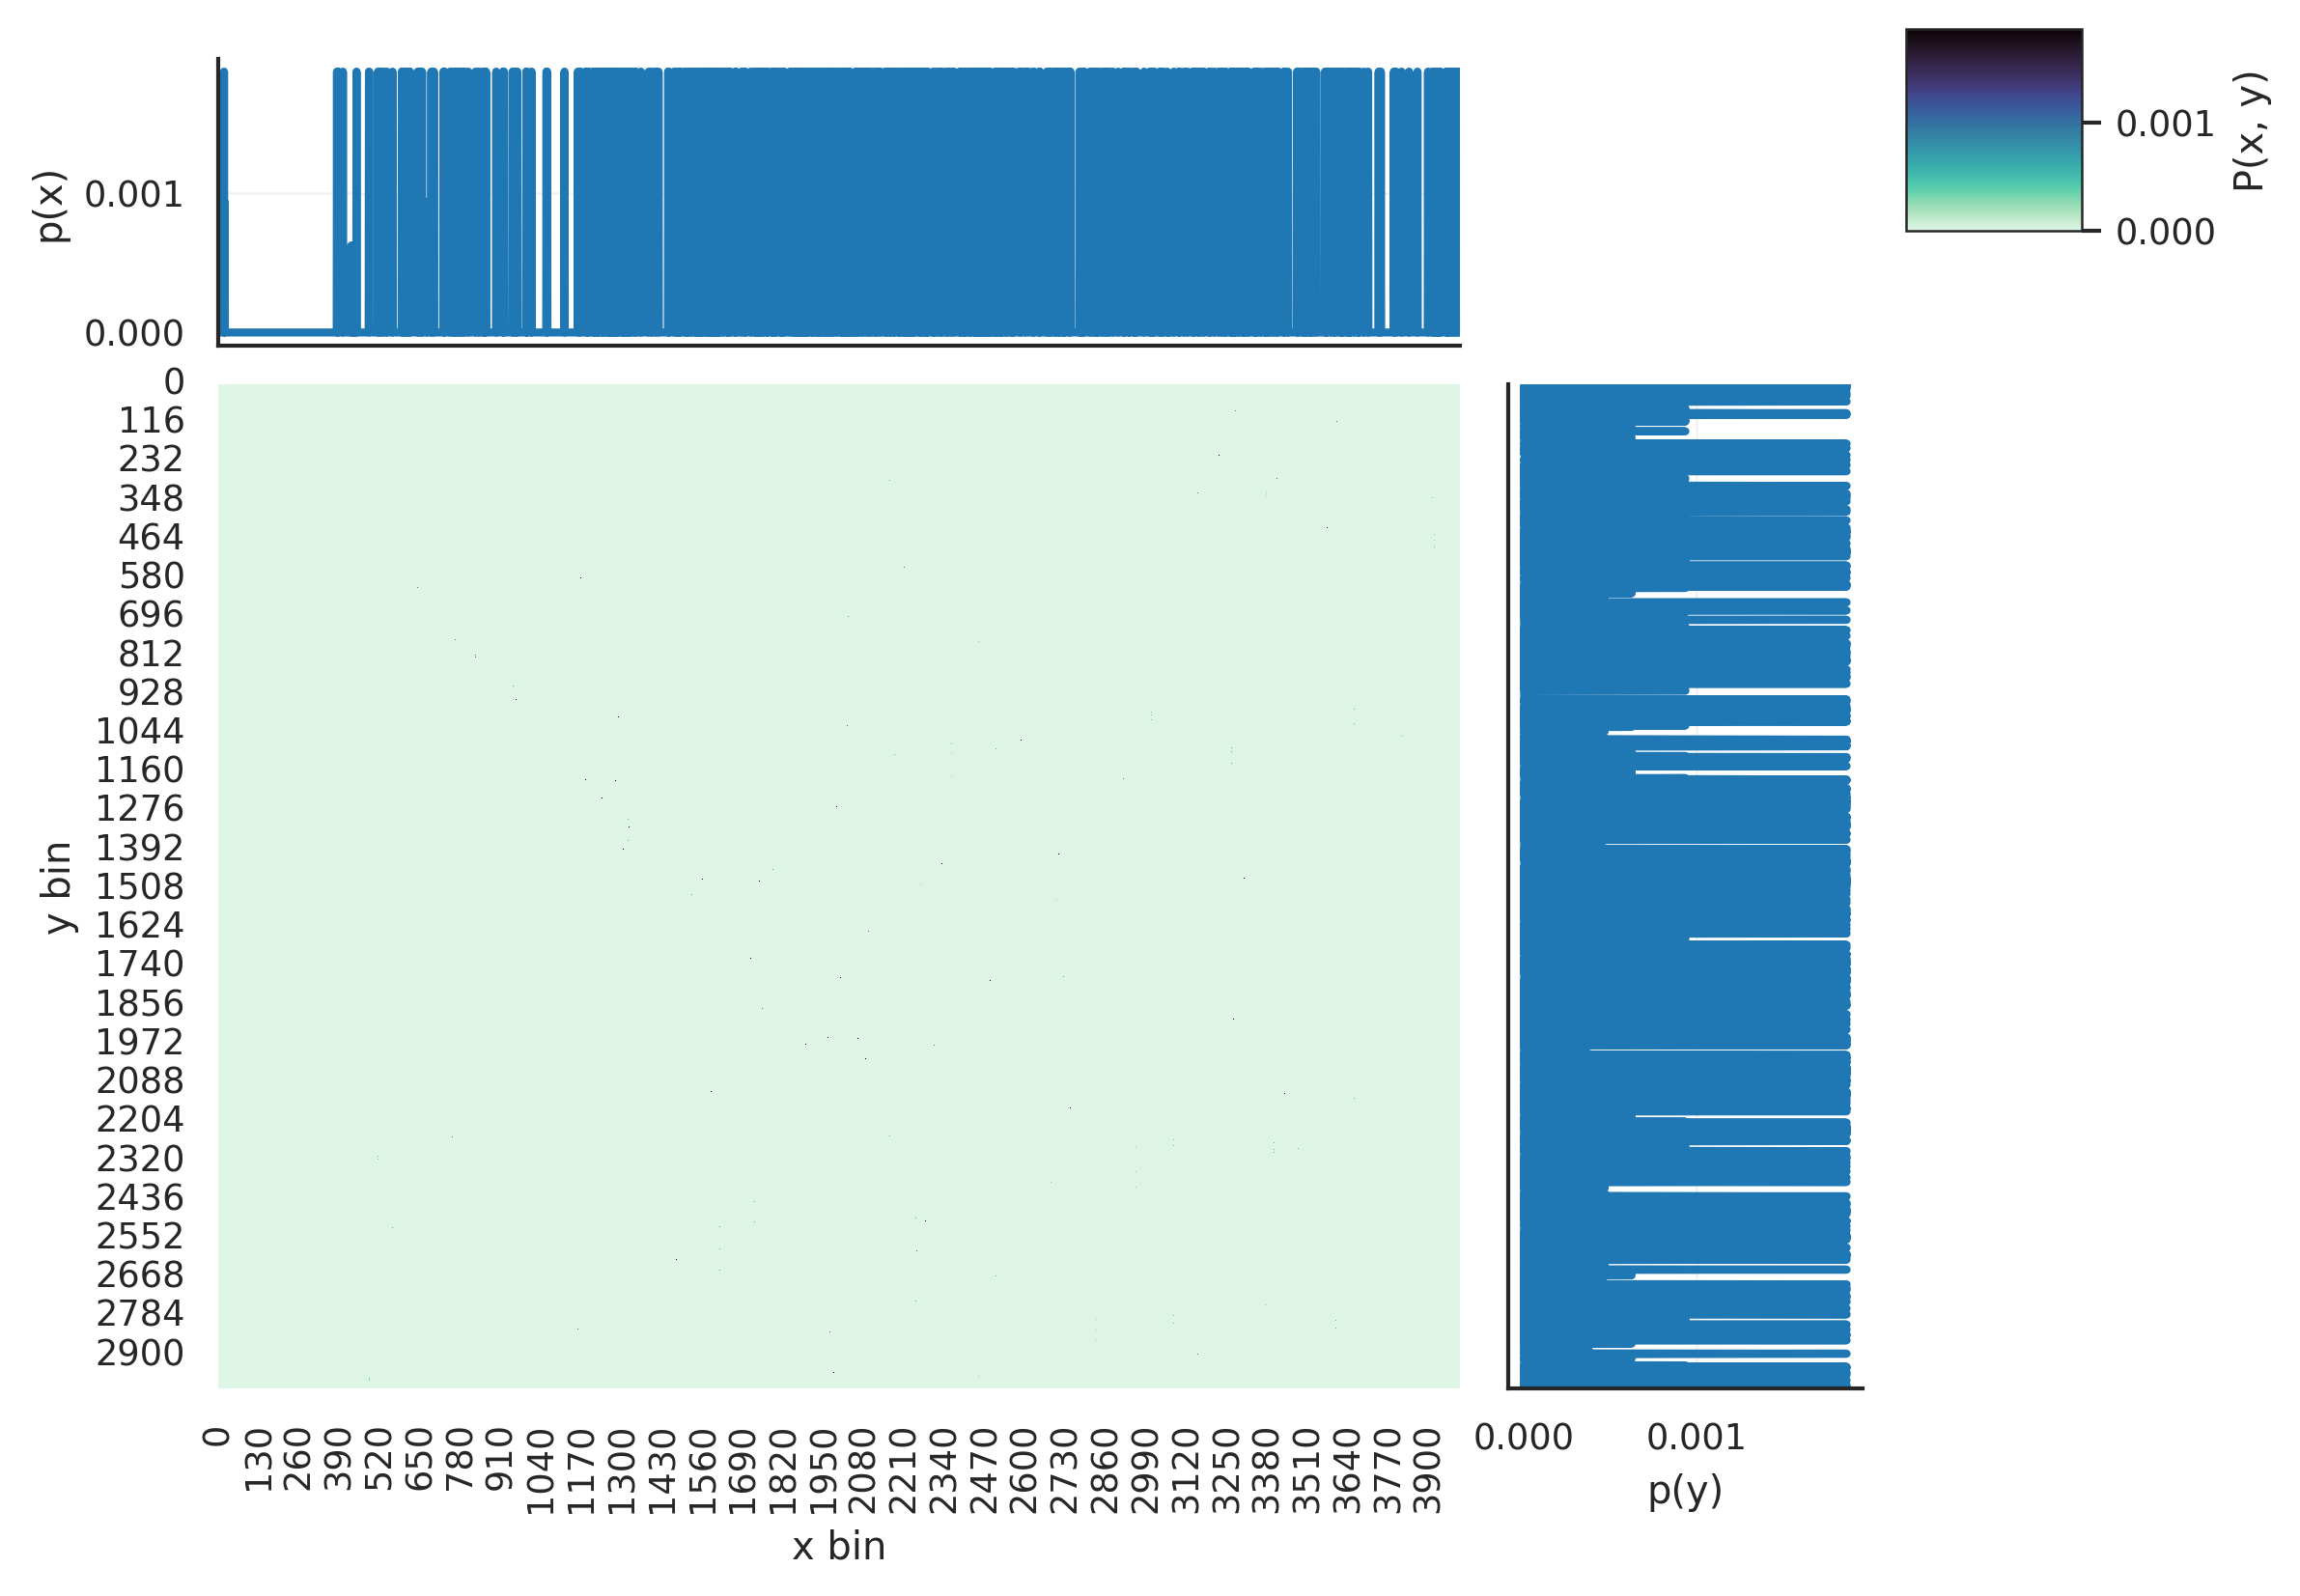

In [30]:
plot_marginal(pi)
print('Done')

### Description

In [4]:
category = "CG"
import src.evaluate as eval
family = load_family_data(Path(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1"))
sim_mat = eval._similarity_matrix_from_file(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim", 
source_nodes=list(family.graphs["A"].nodes()), target_nodes=list(family.graphs["B"].nodes()))

2026-01-11 15:17:22,119 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2026-01-11 15:17:22,160 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2026-01-11 15:17:22,216 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2026-01-11 15:17:22,218 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2026-01-11 15:17:22,643 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


In [6]:
def describe_family(family: FamilyData):
    G = family.graphs["A"]
    print("====== 网络结构指标 ======")
    sigma_value, is_small_world = get_small_worldness(G, n_iter=10)
    print(f"1. 小世界性 (Small-worldness):")
    print(f"\tσ = {sigma_value:.4f}，判定{'是' if is_small_world else '否'}为小世界网络")
    
    clustering, is_clustering = get_clustering(G, n_iter=10)
    print(f"2. 聚类系数 (Clustering coefficient):")
    print(f"\t平均聚类系数 = {clustering:.4f}，判定{'有' if is_clustering else '无'}明显聚类结构")
    
    gamma_value, r_value, is_scale_free = get_scale_free_ness(G)
    print(f"3. 无标度性 (Scale-freeness):")
    print(f"\t度分布指数 γ = {gamma_value:.4f}，相关系数 r = {r_value:.4f}")
    print(f"\t判定{'是' if is_scale_free else '否'}为无标度网络")

    print("========================")

describe_family(family)

====== 网络结构指标 ======


2026-01-11 16:11:28,563 | INFO | src.process | Iteration: 0
2026-01-11 16:11:33,685 | INFO | src.process | Iteration: 1
2026-01-11 16:11:40,041 | INFO | src.process | Iteration: 2
2026-01-11 16:11:46,168 | INFO | src.process | Iteration: 3
2026-01-11 16:11:52,222 | INFO | src.process | Iteration: 4
2026-01-11 16:11:58,444 | INFO | src.process | Iteration: 5
2026-01-11 16:12:05,158 | INFO | src.process | Iteration: 6
2026-01-11 16:12:11,238 | INFO | src.process | Iteration: 7
2026-01-11 16:12:17,261 | INFO | src.process | Iteration: 8
2026-01-11 16:12:23,078 | INFO | src.process | Iteration: 9


1. 小世界性 (Small-worldness):
	σ = 144.1799，判定是为小世界网络
2. 聚类系数 (Clustering coefficient):
	平均聚类系数 = 180.1084，判定有明显聚类结构
3. 无标度性 (Scale-freeness):
	度分布指数 γ = 3.2077，相关系数 r = 0.8775
	判定否为无标度网络


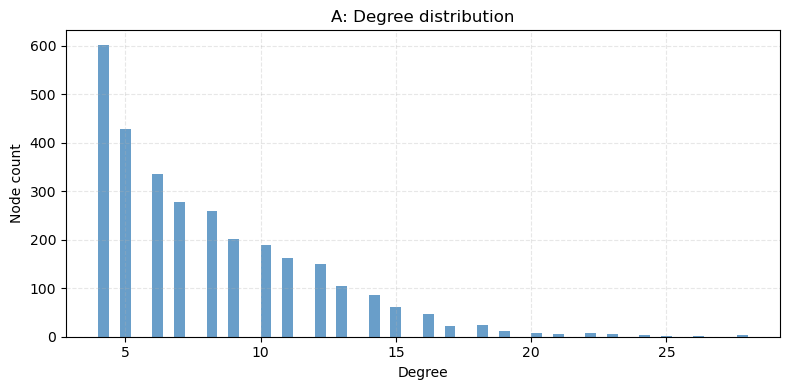

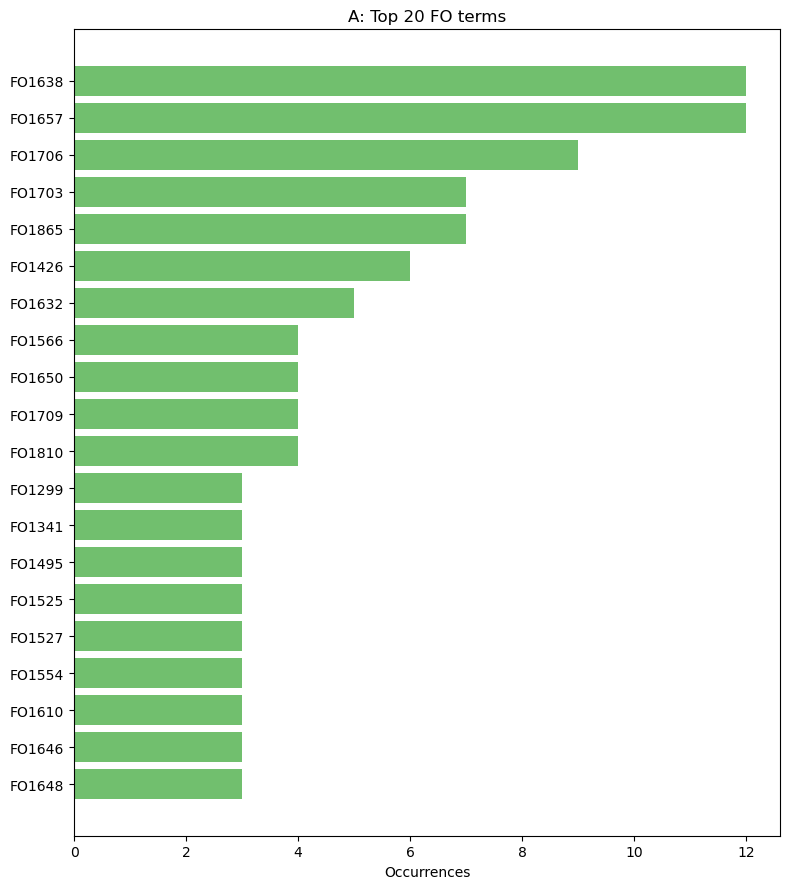

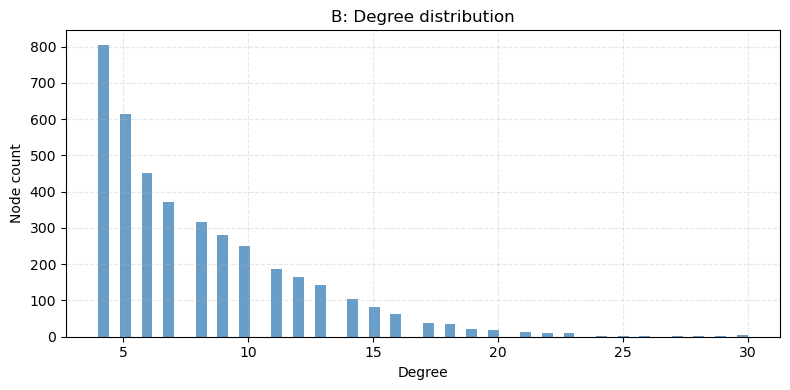

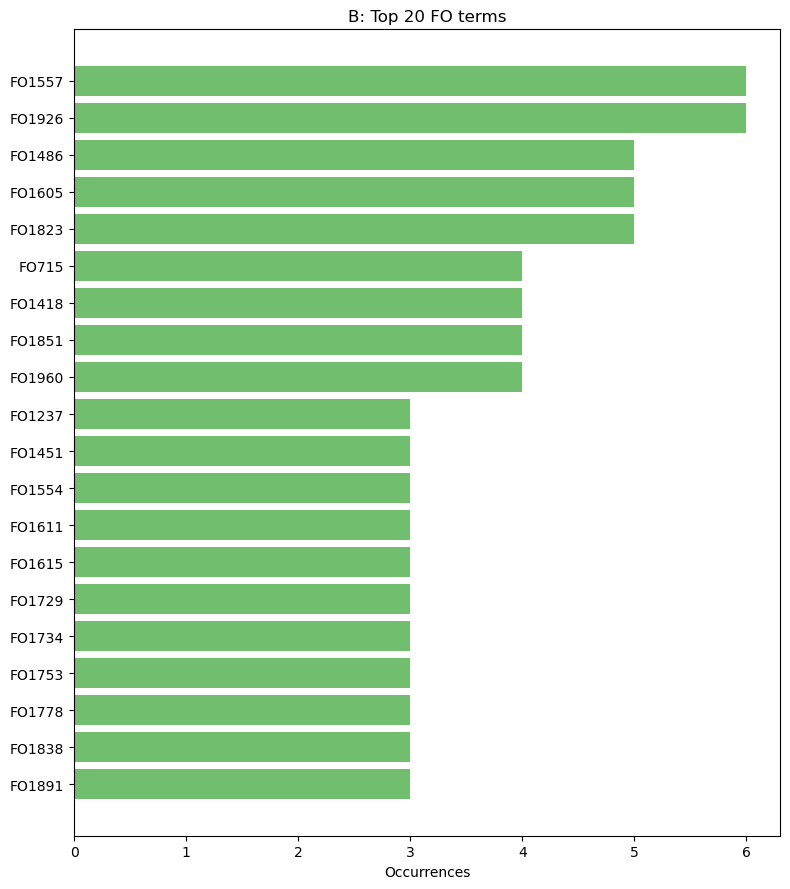

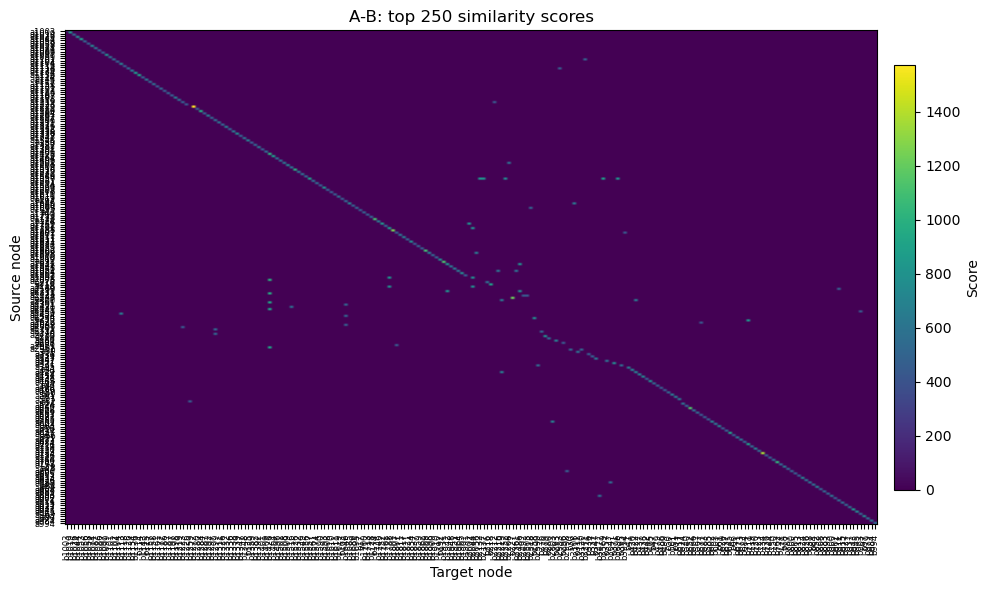

In [8]:
figures = visualize_family(family, similarity_pair=("A", "B"))

### Visualization